CALIFORNIA HOUSING PRICE PREDICTION

📁 Loading California Housing dataset...
✓ Samples: 20,640
✓ Features: 8
✓ Target: House Price (in $100,000s)

📊 Dataset Info:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000

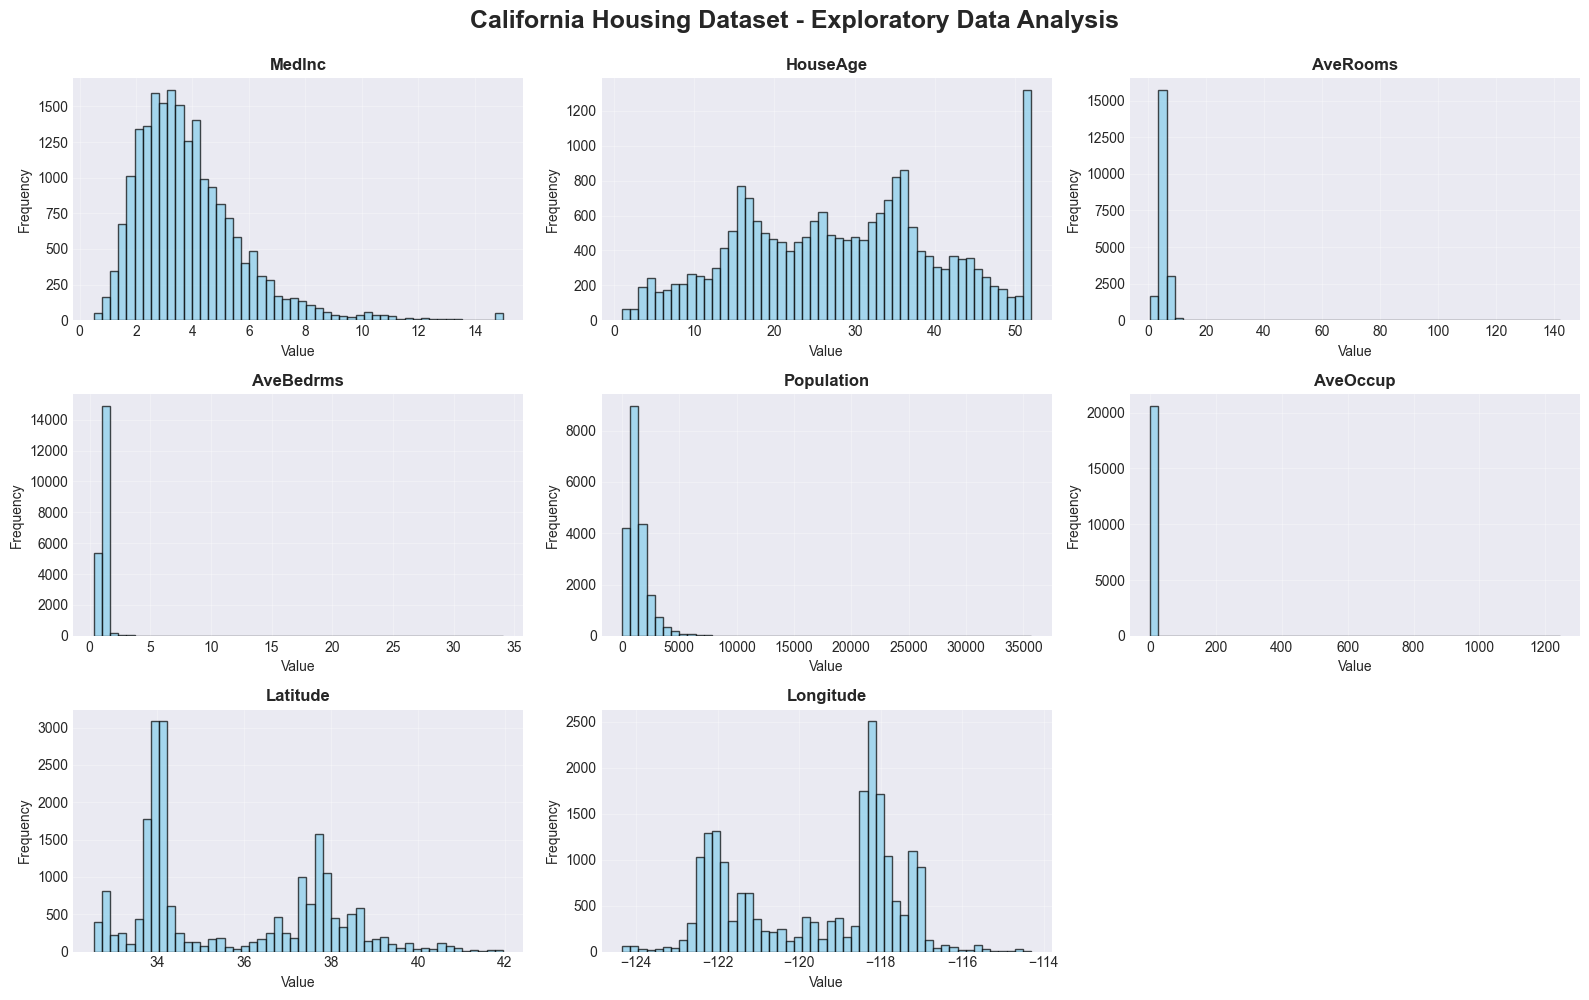

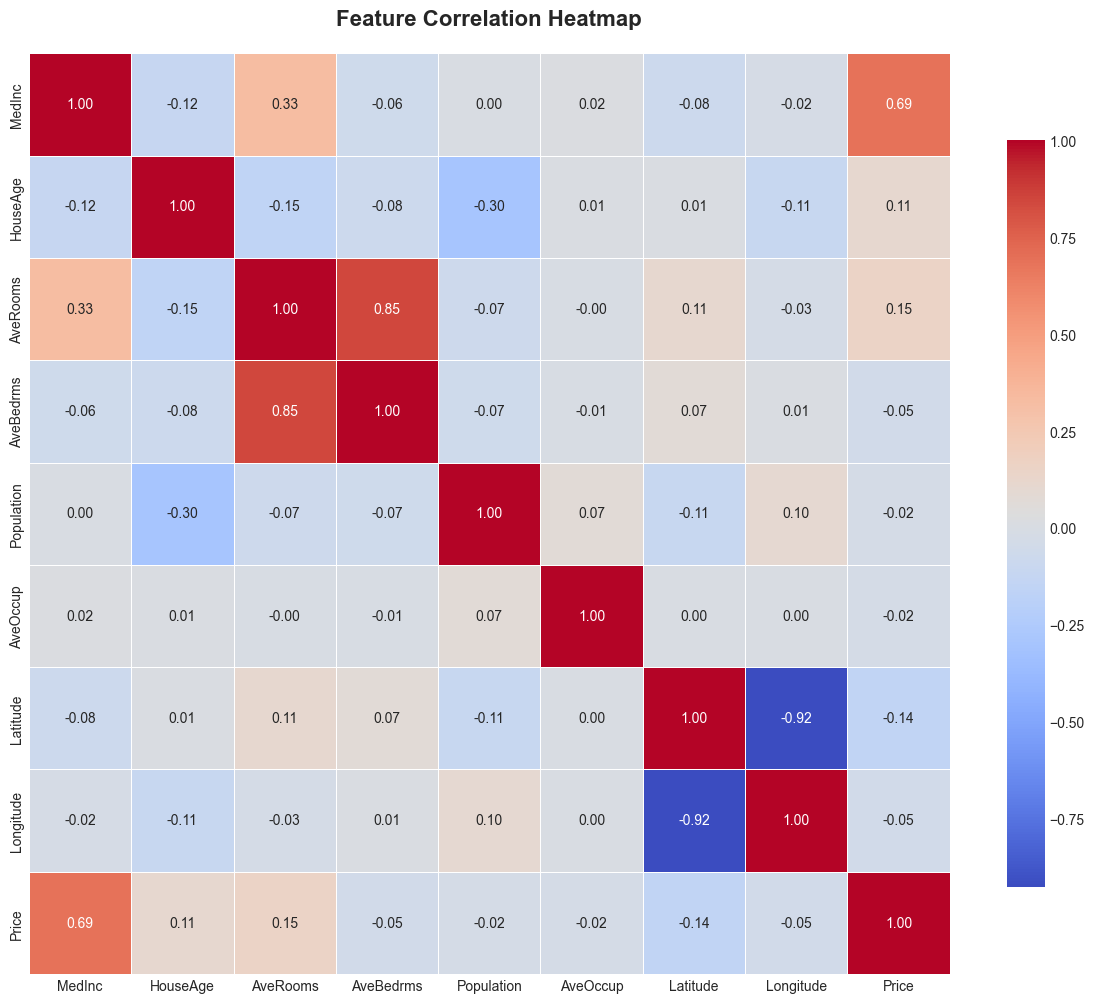

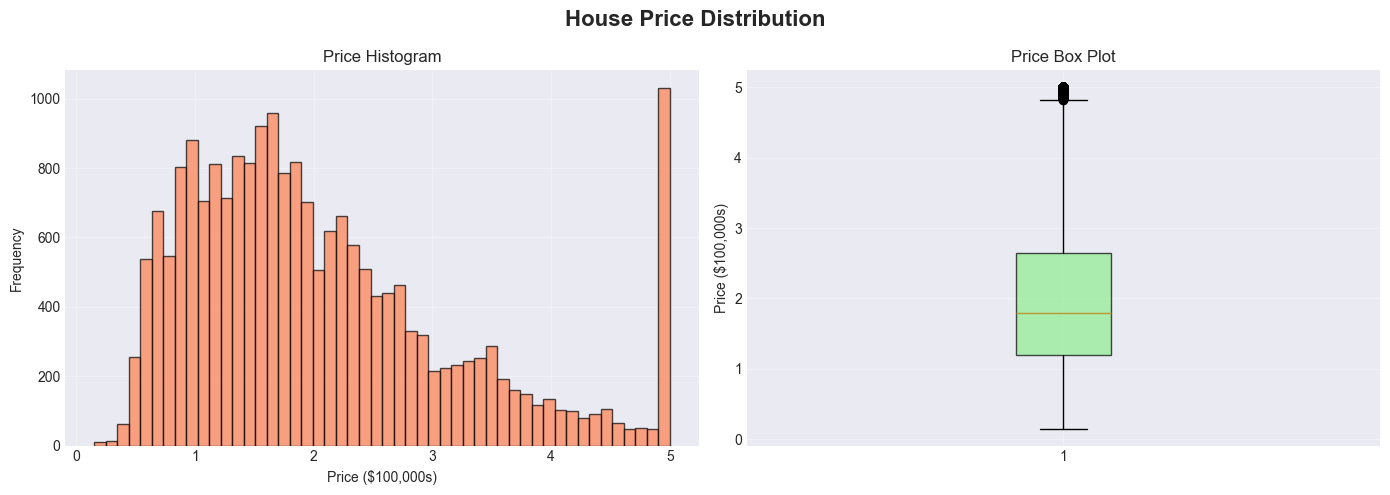


DATA PREPROCESSING

✓ Training samples: 13,209
✓ Validation samples: 3,303
✓ Test samples: 4,128

✓ Features standardized (mean=0, std=1)

BUILDING NEURAL NETWORK

🏗️  Architecture: 8 -> 64 -> 32 -> 16 -> 1

🚀 Training Neural Network...
--------------------------------------------------------------------------------
Epoch    0/1000 - Train Loss: 0.969012 - Val Loss: 1.026537
Epoch  100/1000 - Train Loss: 0.328363 - Val Loss: 0.365391
Epoch  200/1000 - Train Loss: 0.301863 - Val Loss: 0.349628
Epoch  300/1000 - Train Loss: 0.285173 - Val Loss: 0.337455
Epoch  400/1000 - Train Loss: 0.274508 - Val Loss: 0.330308
Epoch  500/1000 - Train Loss: 0.264314 - Val Loss: 0.325932
Epoch  600/1000 - Train Loss: 0.257144 - Val Loss: 0.324287
Epoch  700/1000 - Train Loss: 0.252543 - Val Loss: 0.325995
Epoch  800/1000 - Train Loss: 0.244779 - Val Loss: 0.315309
Epoch  900/1000 - Train Loss: 0.240867 - Val Loss: 0.318109
Epoch  999/1000 - Train Loss: 0.237520 - Val Loss: 0.314278
---------------------

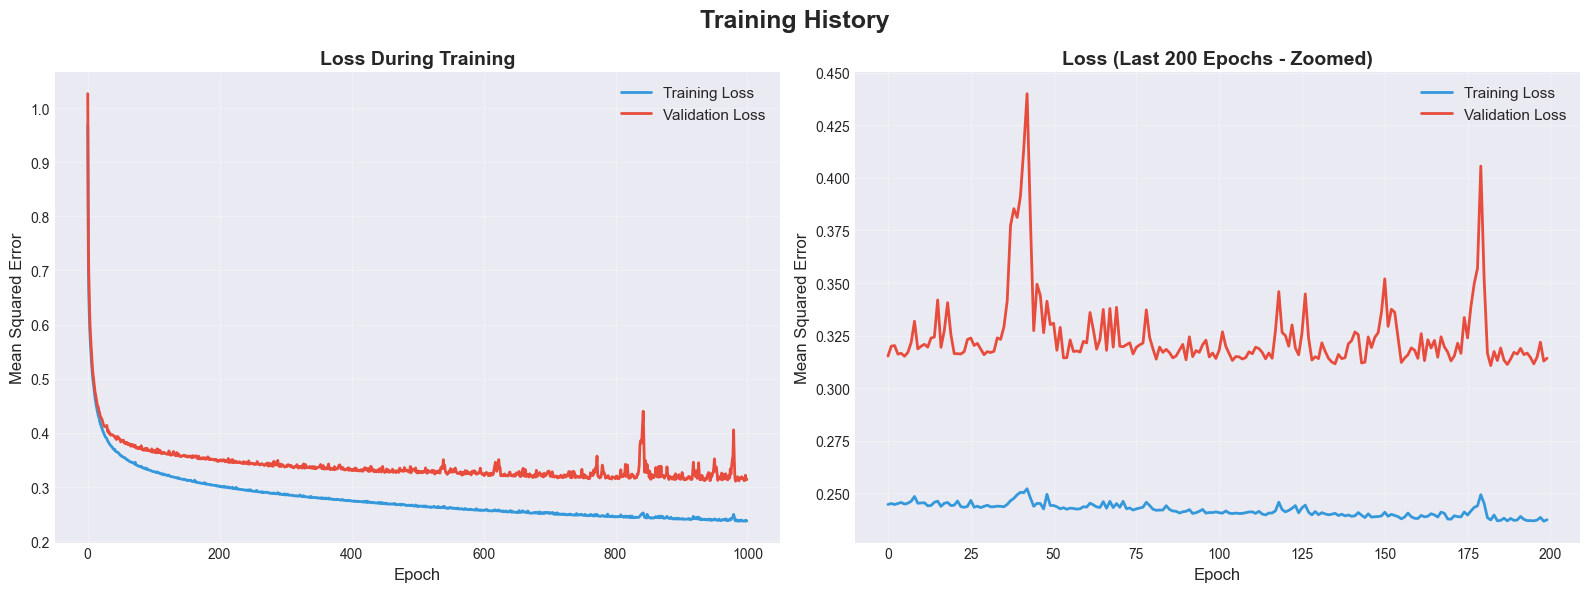

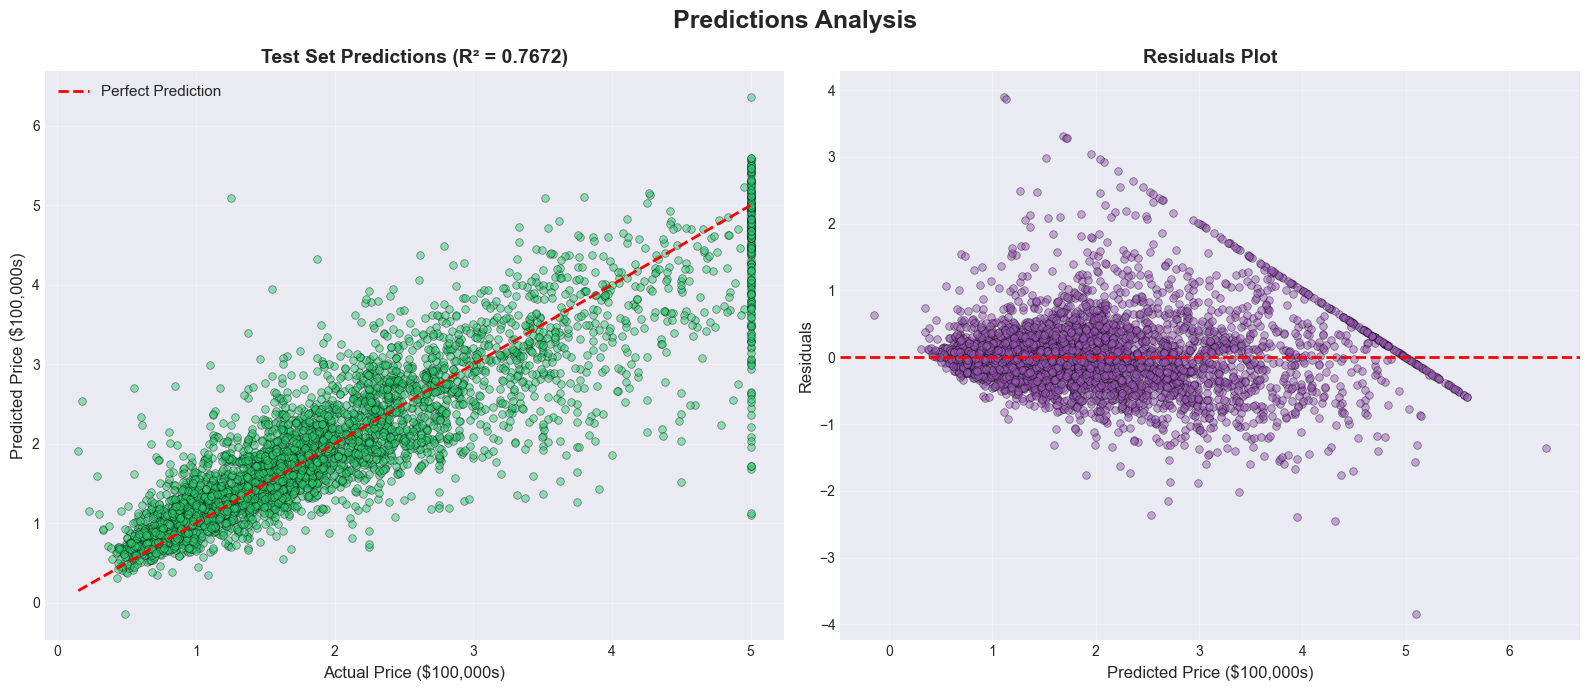

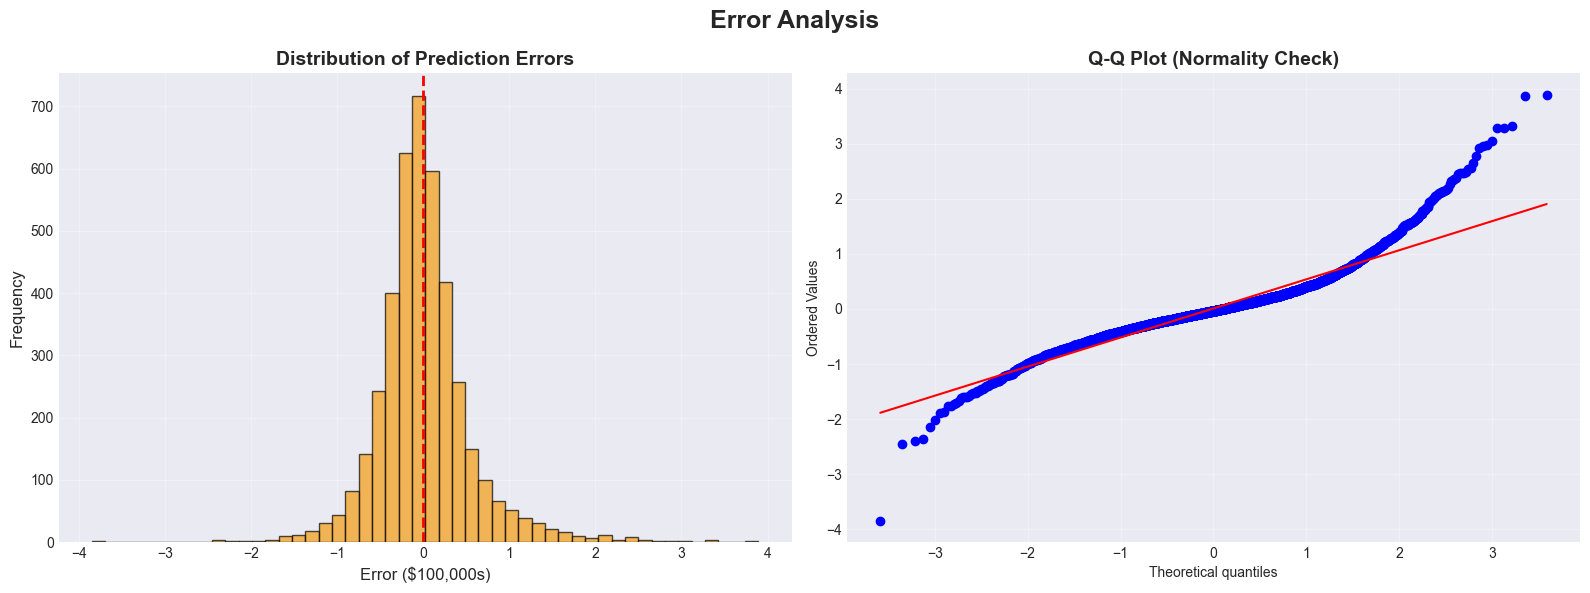


📋 Sample Predictions (First 10 Test Samples):
--------------------------------------------------------------------------------
    Actual |  Predicted |      Error |    Error %
--------------------------------------------------------------------------------
    0.4770 |     0.4927 |    -0.0157 |     -3.30%
    0.4580 |     1.1582 |    -0.7002 |   -152.87%
    5.0000 |     5.1838 |    -0.1838 |     -3.68%
    2.1860 |     2.5170 |    -0.3310 |    -15.14%
    2.7800 |     3.3393 |    -0.5593 |    -20.12%
    1.5870 |     1.8031 |    -0.2161 |    -13.61%
    1.9820 |     2.4305 |    -0.4485 |    -22.63%
    1.5750 |     1.4779 |     0.0971 |      6.17%
    3.4000 |     2.2722 |     1.1278 |     33.17%
    4.4660 |     4.7232 |    -0.2572 |     -5.76%

FEATURE IMPORTANCE ANALYSIS

📊 Feature Importance (based on first layer weights):
   Feature  Importance
  AveOccup    0.147371
  HouseAge    0.136141
  AveRooms    0.128592
  Latitude    0.121740
    MedInc    0.120935
 Longitude    0.1183

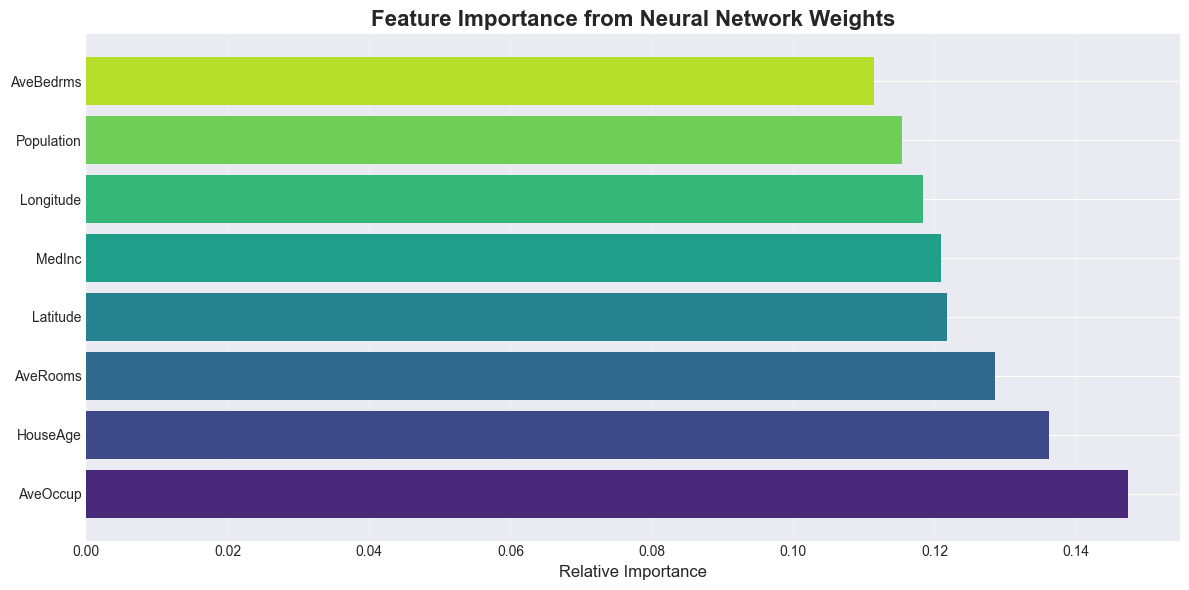


🎉 PROJECT COMPLETE!

📌 Summary:
  • Dataset: California Housing (20,640 samples)
  • Features: 8
  • Architecture: 8 -> 64 -> 32 -> 16 -> 1
  • Training Samples: 13,209
  • Test Samples: 4,128
  • Test R² Score: 0.7672
  • Test RMSE: $55.23k
  • Training Epochs: 1000

✨ Visualizations Created:
  ✓ Dataset exploratory analysis
  ✓ Correlation heatmap
  ✓ Training/validation loss curves
  ✓ Actual vs predicted scatter plot
  ✓ Residuals analysis
  ✓ Error distribution
  ✓ Feature importance



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# NEURAL NETWORK CLASS FROM SCRATCH
class NeuralNetwork:
    """Neural Network with visualization capabilities"""
    
    def __init__(self, layer_sizes, learning_rate=0.001, activation='relu'):
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes)
        self.activation_name = activation
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        
        for i in range(self.num_layers - 1):
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)
        
        # Training history
        self.train_losses = []
        self.val_losses = []
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def linear(self, x):
        return x
    
    def linear_derivative(self, x):
        return np.ones_like(x)
    
    def forward(self, X):
        """Forward propagation"""
        activations = [X]
        z_values = []
        
        for i in range(self.num_layers - 1):
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            z_values.append(z)
            
            # Use ReLU for hidden layers, linear for output
            if i == self.num_layers - 2:
                a = self.linear(z)
            else:
                a = self.relu(z)
            
            activations.append(a)
        
        return activations, z_values
    
    def backward(self, X, y, activations, z_values):
        """Backward propagation"""
        m = X.shape[0]
        weight_gradients = []
        bias_gradients = []
        
        # Output layer gradient (MSE loss)
        delta = (activations[-1] - y) / m
        
        for i in range(self.num_layers - 2, -1, -1):
            dW = np.dot(activations[i].T, delta)
            db = np.sum(delta, axis=0, keepdims=True)
            
            weight_gradients.insert(0, dW)
            bias_gradients.insert(0, db)
            
            if i > 0:
                delta = np.dot(delta, self.weights[i].T) * self.relu_derivative(z_values[i - 1])
        
        return weight_gradients, bias_gradients
    
    def compute_loss(self, y_true, y_pred):
        """Mean Squared Error"""
        return np.mean((y_true - y_pred) ** 2)
    
    def train(self, X_train, y_train, X_val, y_val, epochs=1000, batch_size=32, verbose=True):
        """Train the network with mini-batch gradient descent"""
        n_samples = X_train.shape[0]
        
        for epoch in range(epochs):
            # Shuffle data
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            # Mini-batch training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                # Forward pass
                activations, z_values = self.forward(X_batch)
                
                # Backward pass
                weight_gradients, bias_gradients = self.backward(X_batch, y_batch, activations, z_values)
                
                # Update parameters
                for j in range(len(self.weights)):
                    self.weights[j] -= self.learning_rate * weight_gradients[j]
                    self.biases[j] -= self.learning_rate * bias_gradients[j]
            
            # Compute losses
            train_pred, _ = self.forward(X_train)
            train_loss = self.compute_loss(y_train, train_pred[-1])
            self.train_losses.append(train_loss)
            
            val_pred, _ = self.forward(X_val)
            val_loss = self.compute_loss(y_val, val_pred[-1])
            self.val_losses.append(val_loss)
            
            if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:4d}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
    
    def predict(self, X):
        """Make predictions"""
        activations, _ = self.forward(X)
        return activations[-1]

# LOAD AND EXPLORE DATASET

print("=" * 80)
print("CALIFORNIA HOUSING PRICE PREDICTION")
print("=" * 80)

# Load dataset
print("\n Loading California Housing dataset...")
housing = fetch_california_housing()
X = housing.data
y = housing.target.reshape(-1, 1)
feature_names = housing.feature_names

print(f" Samples: {X.shape[0]:,}")
print(f" Features: {X.shape[1]}")
print(f" Target: House Price (in $100,000s)")

# Create DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['Price'] = y

print(f"\n Dataset Info:")
print(df.describe())

# Visualize dataset
fig = plt.figure(figsize=(16, 10))
fig.suptitle('California Housing Dataset - Exploratory Data Analysis', 
             fontsize=18, fontweight='bold', y=0.995)

# Feature distributions
for i, col in enumerate(feature_names):
    plt.subplot(3, 3, i+1)
    plt.hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(col, fontweight='bold')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price Distribution', fontsize=16, fontweight='bold')

axes[0].hist(df['Price'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Histogram')
axes[0].set_xlabel('Price ($100,000s)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['Price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[1].set_title('Price Box Plot')
axes[1].set_ylabel('Price ($100,000s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  DATA PREPROCESSING

print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]:,}")
print(f" Validation samples: {X_val.shape[0]:,}")
print(f" Test samples: {X_test.shape[0]:,}")

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\n✓ Features standardized (mean=0, std=1)")

#  BUILD AND TRAIN NEURAL NETWORK
print("\n" + "=" * 80)
print("BUILDING NEURAL NETWORK")
print("=" * 80)

# Network architecture: 8 -> 64 -> 32 -> 16 -> 1
layer_sizes = [8, 64, 32, 16, 1]
print(f"\nArchitecture: {' -> '.join(map(str, layer_sizes))}")

# Create and train network
nn = NeuralNetwork(layer_sizes=layer_sizes, learning_rate=0.001, activation='relu')

print("\n Training Neural Network...")
print("-" * 80)
nn.train(X_train, y_train, X_val, y_val, epochs=1000, batch_size=32, verbose=True)
print("-" * 80)
print("✓ Training Complete!")

#  EVALUATE MODEL
print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Make predictions
y_train_pred = nn.predict(X_train)
y_val_pred = nn.predict(X_val)
y_test_pred = nn.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTraining Set Metrics:")
print(f"  • MSE:  {train_mse:.4f}")
print(f"  • RMSE: {train_rmse:.4f}")
print(f"  • MAE:  {train_mae:.4f}")
print(f"  • R² Score: {train_r2:.4f}")

print(f"\nTest Set Metrics:")
print(f"  • MSE:  {test_mse:.4f}")
print(f"  • RMSE: {test_rmse:.4f}")
print(f"  • MAE:  {test_mae:.4f}")
print(f"  • R² Score: {test_r2:.4f}")

# VISUALIZE TRAINING PROCESS

print("\n" + "=" * 80)
print("VISUALIZING RESULTS")
print("=" * 80)

# Training history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History', fontsize=18, fontweight='bold')

# Loss curves
axes[0].plot(nn.train_losses, label='Training Loss', linewidth=2, color='#3498db')
axes[0].plot(nn.val_losses, label='Validation Loss', linewidth=2, color='#e74c3c')
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Mean Squared Error', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Zoomed loss (last 200 epochs)
axes[1].plot(nn.train_losses[-200:], label='Training Loss', linewidth=2, color='#3498db')
axes[1].plot(nn.val_losses[-200:], label='Validation Loss', linewidth=2, color='#e74c3c')
axes[1].set_title('Loss (Last 200 Epochs - Zoomed)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Squared Error', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  PREDICTION VISUALIZATIONS
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Predictions Analysis', fontsize=18, fontweight='bold')

# Scatter plot - Test set
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='#2ecc71', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Test Set Predictions (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Price ($100,000s)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($100,000s)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=30, color='#9b59b6', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuals Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Price ($100,000s)', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Error Analysis', fontsize=18, fontweight='bold')

# Histogram of errors
axes[0].hist(residuals, bins=50, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Error ($100,000s)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Q-Q Plot
from scipy import stats
stats.probplot(residuals.flatten(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sample predictions table
print("\n📋 Sample Predictions (First 10 Test Samples):")
print("-" * 80)
print(f"{'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'Error %':>10}")
print("-" * 80)

for i in range(min(10, len(y_test))):
    actual = y_test[i][0]
    predicted = y_test_pred[i][0]
    error = actual - predicted
    error_pct = (error / actual) * 100
    print(f"{actual:10.4f} | {predicted:10.4f} | {error:10.4f} | {error_pct:9.2f}%")


#  FEATURE IMPORTANCE (WEIGHTS VISUALIZATION)


print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# Analyze first layer weights
first_layer_weights = nn.weights[0]
feature_importance = np.abs(first_layer_weights).mean(axis=1)

# Normalize
feature_importance = feature_importance / feature_importance.sum()

# Sort features by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n Feature Importance (based on first layer weights):")
print(importance_df.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color=sns.color_palette("viridis", len(feature_names)))
plt.xlabel('Relative Importance', fontsize=12)
plt.title('Feature Importance from Neural Network Weights', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#  SUMMARY


print("\n" + "=" * 80)
print(" PROJECT COMPLETE!")
print("=" * 80)

print(f"\n Summary:")
print(f"  • Dataset: California Housing (20,640 samples)")
print(f"  • Features: {X.shape[1]}")
print(f"  • Architecture: {' -> '.join(map(str, layer_sizes))}")
print(f"  • Training Samples: {X_train.shape[0]:,}")
print(f"  • Test Samples: {X_test.shape[0]:,}")
print(f"  • Test R² Score: {test_r2:.4f}")
print(f"  • Test RMSE: ${test_rmse*100:.2f}k")
print(f"  • Training Epochs: {len(nn.train_losses)}")

print("\n Visualizations Created:")
print("  ✓ Dataset exploratory analysis")
print("  ✓ Correlation heatmap")
print("  ✓ Training/validation loss curves")
print("  ✓ Actual vs predicted scatter plot")
print("  ✓ Residuals analysis")
print("  ✓ Error distribution")
print("  ✓ Feature importance")

print("\n" + "=" * 80)